# Week 4 Multimodal Robustness Evaluation

Controlled public-image proxy: 10 Aido Rover and 10 Sentinel Prime AI scenarios, each evaluated clean, with deterministic Gaussian noise, and with a fixed brightness reduction. The same 768x768 source pixels are used across conditions and only one factor changes at a time.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'W04_Multimodal_Summary_v0.1.0.json').exists():
    ROOT = Path.cwd() / 'phase_b_evaluation'
summary = json.loads((ROOT / 'W04_Multimodal_Summary_v0.1.0.json').read_text(encoding='utf-8'))
assert summary['scenario_count'] == 20
assert summary['row_count'] == 60
summary['controlled_input_statement']

'Each scenario uses the same 768x768 clean pixels with exactly one deterministic factor changed: Gaussian noise or brightness.'

In [2]:
condition_df = pd.DataFrame(summary['conditions'])
robustness_df = pd.DataFrame(summary['perturbation_robustness'])
platform_df = pd.DataFrame(summary['platform_conditions'])
display(condition_df[['condition_id', 'parsed_row_count', 'mean_total_score', 'acceptable_decision_rate', 'forbidden_claim_rate']])
display(robustness_df)

,condition_id,parsed_row_count,mean_total_score,acceptable_decision_rate,forbidden_claim_rate
0,clean,20,4.90,0.95,0.00
1,gaussian_noise_std_0.08,20,4.80,0.90,0.05
2,brightness_0.60,20,4.75,0.90,0.00


,condition_id,decision_consistency_clean_vs_perturbed,eligible_scenario_count,mean_clean_to_perturbed_score_drop
0,gaussian_noise_std_0.08,0.95,20,0.10
1,brightness_0.60,0.95,20,0.15


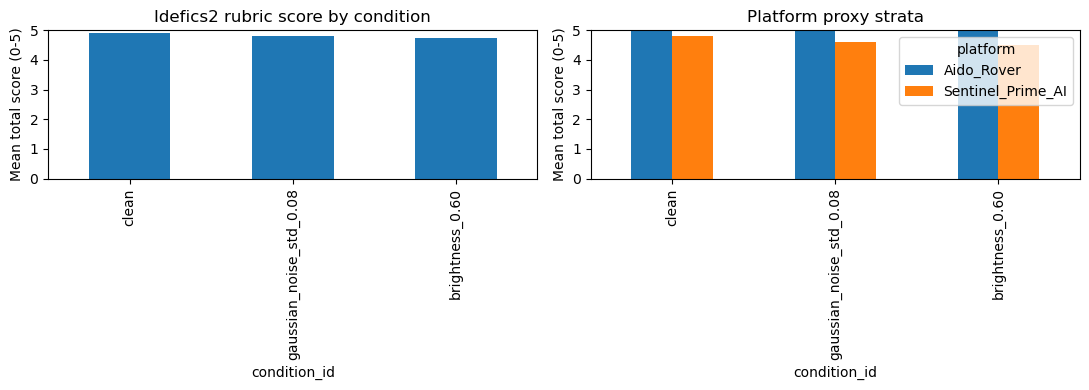

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
condition_df.plot.bar(x='condition_id', y='mean_total_score', ylim=(0, 5), legend=False, ax=axes[0], title='Idefics2 rubric score by condition')
pivot = platform_df.pivot(index='condition_id', columns='platform', values='mean_total_score')
pivot.reindex(condition_df['condition_id']).plot.bar(ylim=(0, 5), ax=axes[1], title='Platform proxy strata')
axes[0].set_ylabel('Mean total score (0-5)')
axes[1].set_ylabel('Mean total score (0-5)')
plt.tight_layout()

In [4]:
performance = json.loads((ROOT / 'W04_System_Performance_Summary_v0.1.0.json').read_text(encoding='utf-8'))
vlm_perf = []
for group in performance['groups']:
    if group['candidate_model_key'] != 'idefics2_8b_chatty':
        continue
    e2e = group['latency_ms']['question_to_response_ms']
    ttft = group['latency_ms']['ttft_ms']
    gpu = group['resources']['gpu_device_memory_used_peak_mib']
    vlm_perf.append({
        'condition': group['condition_id'], 'n': group['row_count'],
        'e2e_p50_ms': e2e['p50'], 'e2e_p95_ms': e2e['p95'],
        'ttft_p50_ms': ttft['p50'], 'gpu_peak_max_mib': gpu['max'],
    })
display(pd.DataFrame(vlm_perf))
display(pd.DataFrame([row for row in performance['run_static'] if row['candidate_model_key'] == 'idefics2_8b_chatty']))

,condition,n,e2e_p50_ms,e2e_p95_ms,ttft_p50_ms,gpu_peak_max_mib
0,brightness_0.60,20,6112.253199,7139.544569,788.209877,18407.0
1,clean,20,6717.243544,6949.184772,757.432729,18670.0
2,gaussian_noise_std_0.08,20,6172.386473,7308.984845,767.225444,18407.0


,candidate_model_id,candidate_model_key,candidate_model_revision,checkpoint_bytes,cuda_runtime,driver_version,driver_version_unavailability_reason,gpu_memory_total_mib,gpu_name,host_ram_total_mib,...,model_load_gpu_memory_peak_mib,model_load_gpu_power_peak_w,model_load_gpu_utilization_peak_pct,model_load_ms,model_load_process_rss_peak_mib,precision,python_version,source_file,torch_version,transformers_version
0,HuggingFaceM4/idefics2-8b-chatty,idefics2_8b_chatty,8e65868b394317b973bd61db3b08e6478ebeedbf,33613585188,12.8,None,environment_manifest_v0.1.0_did_not_capture_dr...,46068.0,NVIDIA A40,515598.535156,...,16339.0,111.34,24.0,12154.239088,32652.730469,bfloat16,3.12.3,idefics2_8b_chatty_Run_Sessions.jsonl,2.8.0+cu128,5.14.1


## Interpretation guardrail

This is a single-VLM controlled comparison, not a claim about deployed sensor fusion. AI-assisted 2+2+1 rubric scores are diagnostic; clean-to-perturbed decision flips and forbidden-claim flags are retained in the private review queue.